In [1]:
import tensorflow as tf
from livelossplot import PlotLossesKeras
import matplotlib.pyplot as plt
import numpy as np
from utils.load import load_data
from utils.handlers import get_average
import math
from PIL import Image
import torchvision
import pickle

In [2]:
tf.__version__

'2.10.0'

In [3]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.RandomAffine(degrees=3, scale=(.8, 1.1)),
    torchvision.transforms.RandomPerspective(.3),
    torchvision.transforms.RandomAutocontrast(),
    torchvision.transforms.ColorJitter(.5,.5,.5,.3),
    torchvision.transforms.RandomInvert(.3),

])


In [4]:
class MySequense(tf.keras.utils.Sequence):
    def __init__(self, x_set, y_set, batch_size):
        self.x, self.y = x_set, y_set
        self.batch_size = batch_size

    def __len__(self):
        return math.ceil(len(self.x) / self.batch_size)

    def __getitem__(self, idx):
        batch_x = self.x[idx * self.batch_size:(idx + 1) *
                                               self.batch_size]
        batch_y = self.y[idx * self.batch_size:(idx + 1) *
                                               self.batch_size]

        return np.array([
            np.asarray(transform(Image.fromarray(np.uint8(x)))) / 255.
            for x in batch_x]), np.array(batch_y)

In [5]:
def defective_pixels(images_data):
    for im in range(len(images_data)):
        for row in range(1, len(images_data[im]) - 1):
            for px in range(1, len(images_data[im][row]) - 1):
                if np.array_equal(images_data[im][row][px], np.array([1., 1., 1.])) or np.array_equal(
                        images_data[im][row][px], np.array([0., 0., 0.])):
                    images_data[im][row][px] = np.array([np.median([images_data[im][row - 1][px][0],
                                                                    images_data[im][row - 1][px - 1][0],
                                                                    images_data[im][row - 1][px + 1][0],
                                                                    images_data[im][row + 1][px][0],
                                                                    images_data[im][row + 1][px - 1][0],
                                                                    images_data[im][row + 1][px + 1][0],
                                                                    images_data[im][row][px + 1][0],
                                                                    images_data[im][row][px - 1][0]]),
                                                         np.median([images_data[im][row - 1][px][1],
                                                                    images_data[im][row - 1][px - 1][1],
                                                                    images_data[im][row - 1][px + 1][0],
                                                                    images_data[im][row + 1][px][1],
                                                                    images_data[im][row + 1][px - 1][1],
                                                                    images_data[im][row + 1][px + 1][1],
                                                                    images_data[im][row][px + 1][1],
                                                                    images_data[im][row][px - 1][1]]),
                                                         np.median([images_data[im][row - 1][px][2],
                                                                    images_data[im][row - 1][px - 1][2],
                                                                    images_data[im][row - 1][px + 1][2],
                                                                    images_data[im][row + 1][px][2],
                                                                    images_data[im][row + 1][px - 1][2],
                                                                    images_data[im][row + 1][px + 1][2],
                                                                    images_data[im][row][px + 1][2],
                                                                    images_data[im][row][px - 1][2]])])
    return images_data[0:len(images_data), 1:-1, 1:-1, 0:3]

In [6]:

def load_data(file_name: str) -> np.ndarray:
    """
    :param file_name: path of filename
    :return: read dataset
    """

    with open(file_name, 'rb') as input_file:
        dataframe = pickle.load(input_file)
    return dataframe


In [7]:
df = load_data('data_train')
labels = df['labels']

In [33]:
arr = df['images'].astype(np.uint8)


arr = defective_pixels(arr/255.)

In [34]:
with open('arr.np.ndarray', 'wb') as f:
    pickle.dump(arr, f)

In [8]:
with open('arr.np.ndarray', 'rb') as f:
    arr = pickle.load(f)

In [9]:
arr.shape


(50000, 30, 30, 3)

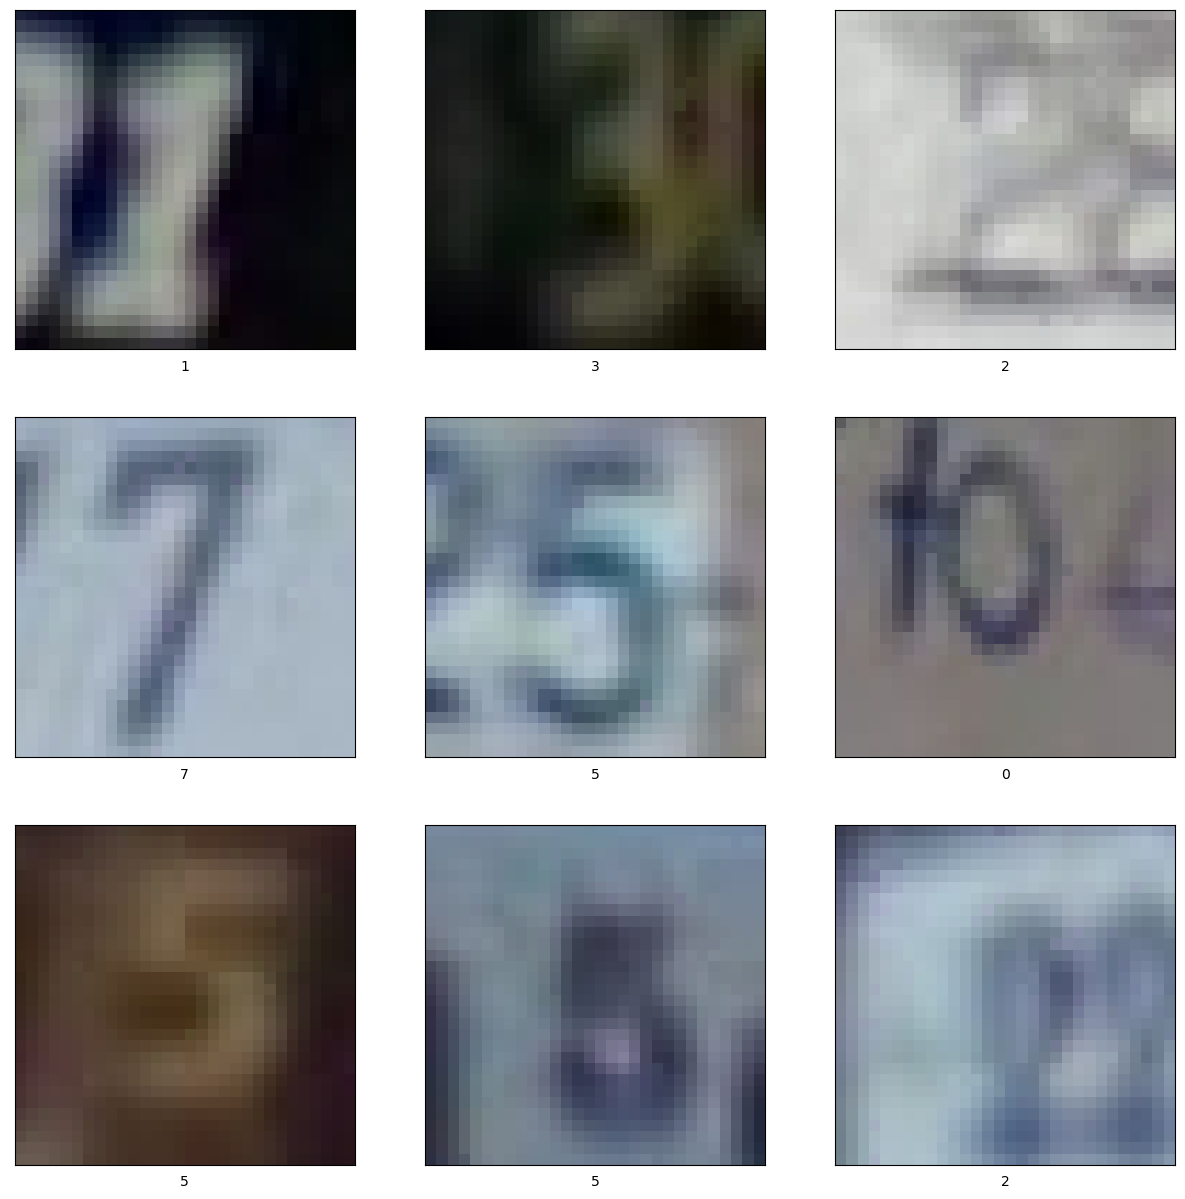

In [10]:
plt.figure(figsize=(15,15))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(arr[i]))
    plt.xlabel(labels[i])

plt.show()

In [11]:
arr = np.uint8(arr * 255)
arr

array([[[[ 26,  32,  56],
         [ 21,  25,  52],
         [ 16,  17,  46],
         ...,
         [  1,   6,  10],
         [  1,   5,   8],
         [  0,   4,   4]],

        [[ 54,  61,  81],
         [ 48,  54,  77],
         [ 43,  48,  74],
         ...,
         [  1,   7,  10],
         [  1,   5,   8],
         [  0,   4,   5]],

        [[ 87,  96, 111],
         [ 80,  89, 105],
         [ 75,  83, 103],
         ...,
         [  2,   7,  10],
         [  1,   6,   8],
         [  0,   4,   5]],

        ...,

        [[ 72,  69,  75],
         [ 45,  43,  50],
         [ 28,  27,  33],
         ...,
         [  7,   7,  10],
         [  7,   8,   9],
         [  7,   9,   8]],

        [[ 36,  31,  40],
         [ 19,  16,  24],
         [ 15,  13,  20],
         ...,
         [  7,   7,   8],
         [  7,   8,   8],
         [  7,   9,   8]],

        [[ 14,   7,  20],
         [  8,   4,  14],
         [ 11,   7,  16],
         ...,
         [  8,   8,   7],
        

In [12]:
from sklearn.model_selection import train_test_split

arr, validation_images, labels, validation_labels = train_test_split(arr, labels, test_size=0.05)

In [13]:
validation_images = validation_images / 255.

In [14]:
ds = MySequense(arr, labels, batch_size=256)


In [15]:

val_dataset = tf.data.Dataset.from_tensor_slices((validation_images,
                                                  validation_labels))

Metal device set to: Apple M1


2022-12-11 12:21:54.787013: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-12-11 12:21:54.787244: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [16]:
input_shape = (30, 30, 3)
input_shape

(30, 30, 3)

In [17]:
batch_size = 256

val_dataset = val_dataset.batch(batch_size)

In [18]:
ds[
    8]

(array([[[[0.83137255, 0.83137255, 0.83137255],
          [0.37647059, 0.39215686, 0.38431373],
          [0.38431373, 0.4       , 0.39215686],
          ...,
          [0.83137255, 0.83137255, 0.83137255],
          [0.83137255, 0.83137255, 0.83137255],
          [0.83137255, 0.83137255, 0.83137255]],
 
         [[0.83137255, 0.83137255, 0.83137255],
          [0.38431373, 0.40392157, 0.4       ],
          [0.38431373, 0.40392157, 0.4       ],
          ...,
          [0.36862745, 0.38039216, 0.38039216],
          [0.37647059, 0.38431373, 0.38039216],
          [0.37647059, 0.38431373, 0.38039216]],
 
         [[0.83137255, 0.83137255, 0.83137255],
          [0.38039216, 0.4       , 0.39215686],
          [0.39215686, 0.41176471, 0.40784314],
          ...,
          [0.38431373, 0.39215686, 0.39215686],
          [0.39215686, 0.40392157, 0.40392157],
          [0.40392157, 0.41176471, 0.41176471]],
 
         ...,
 
         [[0.35686275, 0.38039216, 0.36078431],
          [0.38431

In [45]:
input_layer = tf.keras.layers.Input(shape=input_shape)
c = tf.keras.layers.CenterCrop(27, 27)(input_layer)
# Первый блок:
b1l1 = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(c)
b1l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b1l1)
b1_output = tf.keras.layers.MaxPooling2D()(b1l2)

# Второй блок:
b2l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b1_output)
b2l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b2l1)

# Связываем эти 2 блока
b2b1_output = tf.keras.layers.add([b2l2, b1_output])

# Третий блок:
b3l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b2b1_output)
b3l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b3l1)

# Связываем эти 2 блока
block_3_output = tf.keras.layers.add([b3l2, b2b1_output])

b4l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_3_output)
b4l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b4l1)

block_4_output = tf.keras.layers.add([block_3_output, b4l2])

b5l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_4_output)
b5l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b5l1)

block_5_output = tf.keras.layers.add([block_4_output, b5l2])

b6l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_5_output)
b6l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b6l1)

block_6_output = tf.keras.layers.add([block_5_output, b6l2])

l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_6_output)
l2 = tf.keras.layers.GlobalAveragePooling2D()(l1)
l4 = tf.keras.layers.Dense(256, activation="relu")(l2)
bn = tf.keras.layers.BatchNormalization()(l4)
l5 = tf.keras.layers.Dropout(.1)(bn)
outputs = tf.keras.layers.Dense(10)(l5)


In [46]:
model_kaggle = tf.keras.Model(input_layer, outputs, name="model")

In [47]:
checkpoint_filepath = './CHECKPOINTS'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

checkpoint_filepath = './CHECKPOINTSloss'
model_checkpoint_callback2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_loss',
    mode='min',
    save_best_only=True)


In [48]:
model_kaggle.compile(
    optimizer=tf.keras.optimizers.Adam(decay=3e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])

In [49]:
model_kaggle.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 30, 30, 3)]  0           []                               
                                                                                                  
 center_crop_3 (CenterCrop)     (None, 27, 27, 3)    0           ['input_4[0][0]']                
                                                                                                  
 conv2d_39 (Conv2D)             (None, 27, 27, 32)   896         ['center_crop_3[0][0]']          
                                                                                                  
 conv2d_40 (Conv2D)             (None, 27, 27, 64)   18496       ['conv2d_39[0][0]']              
                                                                                              

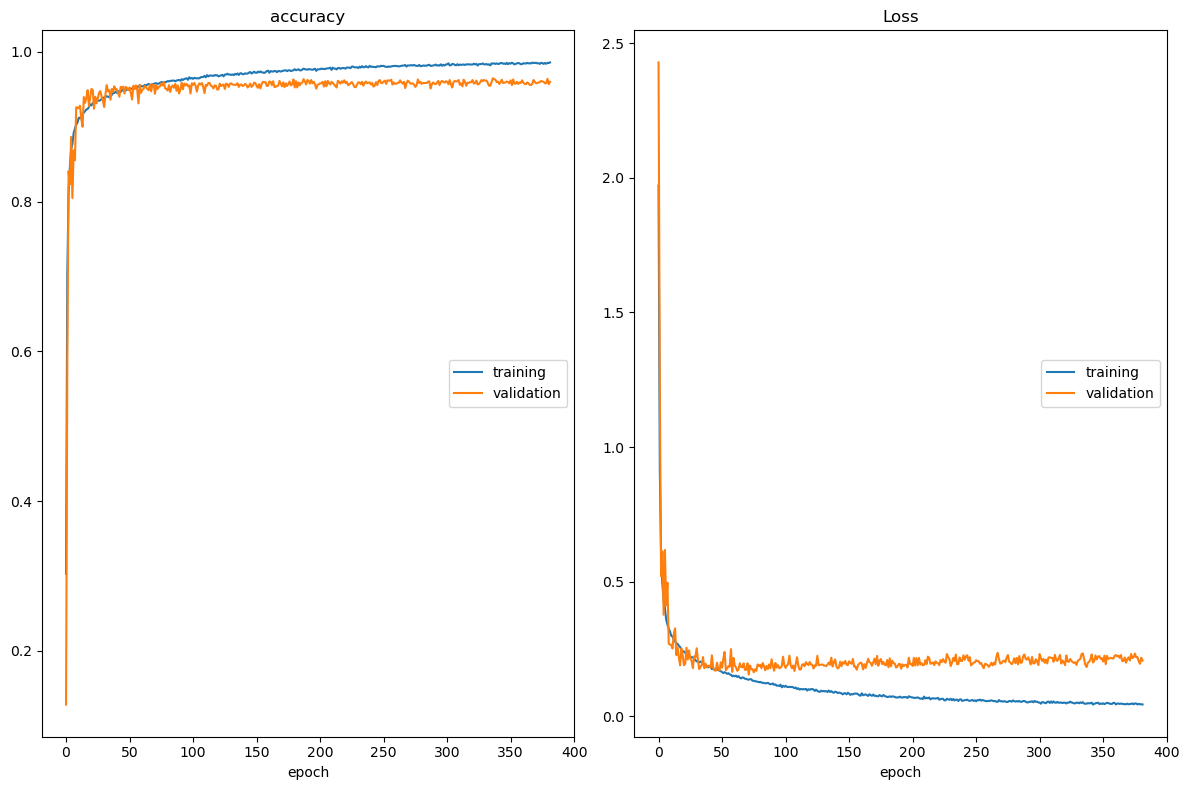

accuracy
	training         	 (min:    0.303, max:    0.986, cur:    0.986)
	validation       	 (min:    0.128, max:    0.965, cur:    0.960)
Loss
	training         	 (min:    0.044, max:    1.971, cur:    0.045)
	validation       	 (min:    0.156, max:    2.428, cur:    0.208)


KeyboardInterrupt: 

In [50]:
model_kagglehist = model_kaggle.fit(ds, validation_data=val_dataset, epochs=400,
                                    callbacks=[PlotLossesKeras(),
                                               model_checkpoint_callback,
                                               model_checkpoint_callback2],
                                    verbose=False, shuffle=True)

In [31]:
dftest = load_data('data_test')


In [32]:
arrtest=dftest['images']

In [33]:

arrtest = np.uint8(arrtest) / 255.
arrtest = defective_pixels(arrtest)
arrtest[0]

array([[[0.28235294, 0.29803922, 0.36078431],
        [0.28627451, 0.29411765, 0.36470588],
        [0.27843137, 0.27843137, 0.35686275],
        ...,
        [0.25882353, 0.29411765, 0.34901961],
        [0.25882353, 0.29411765, 0.34901961],
        [0.25490196, 0.28235294, 0.34509804]],

       [[0.2745098 , 0.29019608, 0.35294118],
        [0.27058824, 0.28039216, 0.34705882],
        [0.2627451 , 0.2627451 , 0.3372549 ],
        ...,
        [0.32156863, 0.34509804, 0.38823529],
        [0.33333333, 0.35686275, 0.39607843],
        [0.3372549 , 0.35686275, 0.39607843]],

       [[0.26666667, 0.28235294, 0.34117647],
        [0.2627451 , 0.27058824, 0.33333333],
        [0.24705882, 0.24705882, 0.32156863],
        ...,
        [0.38431373, 0.39607843, 0.41960784],
        [0.39607843, 0.40980392, 0.4254902 ],
        [0.41960784, 0.42745098, 0.43921569]],

       ...,

       [[0.23137255, 0.27843137, 0.3372549 ],
        [0.21960784, 0.25882353, 0.32941176],
        [0.21176471, 0

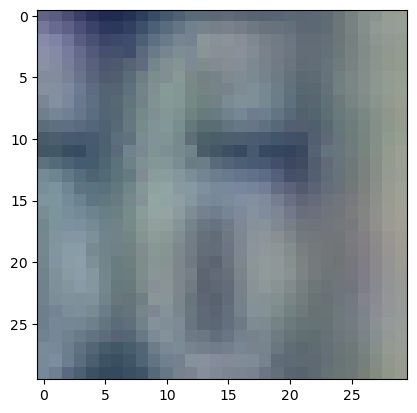

In [51]:
plt.imshow(arrtest[6])

In [52]:
arrtest.shape



(25000, 30, 30, 3)

In [53]:
predictions = model_kaggle.predict(arrtest)

  1/782 [..............................] - ETA: 3:15

2022-12-11 16:01:17.628584: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


782/782 [==============================] - 7s 8ms/step


In [54]:
classes = np.argmax(predictions, axis=1)
classes
# 5 4 1 ... 0 9 2

array([5, 4, 1, ..., 0, 9, 2])

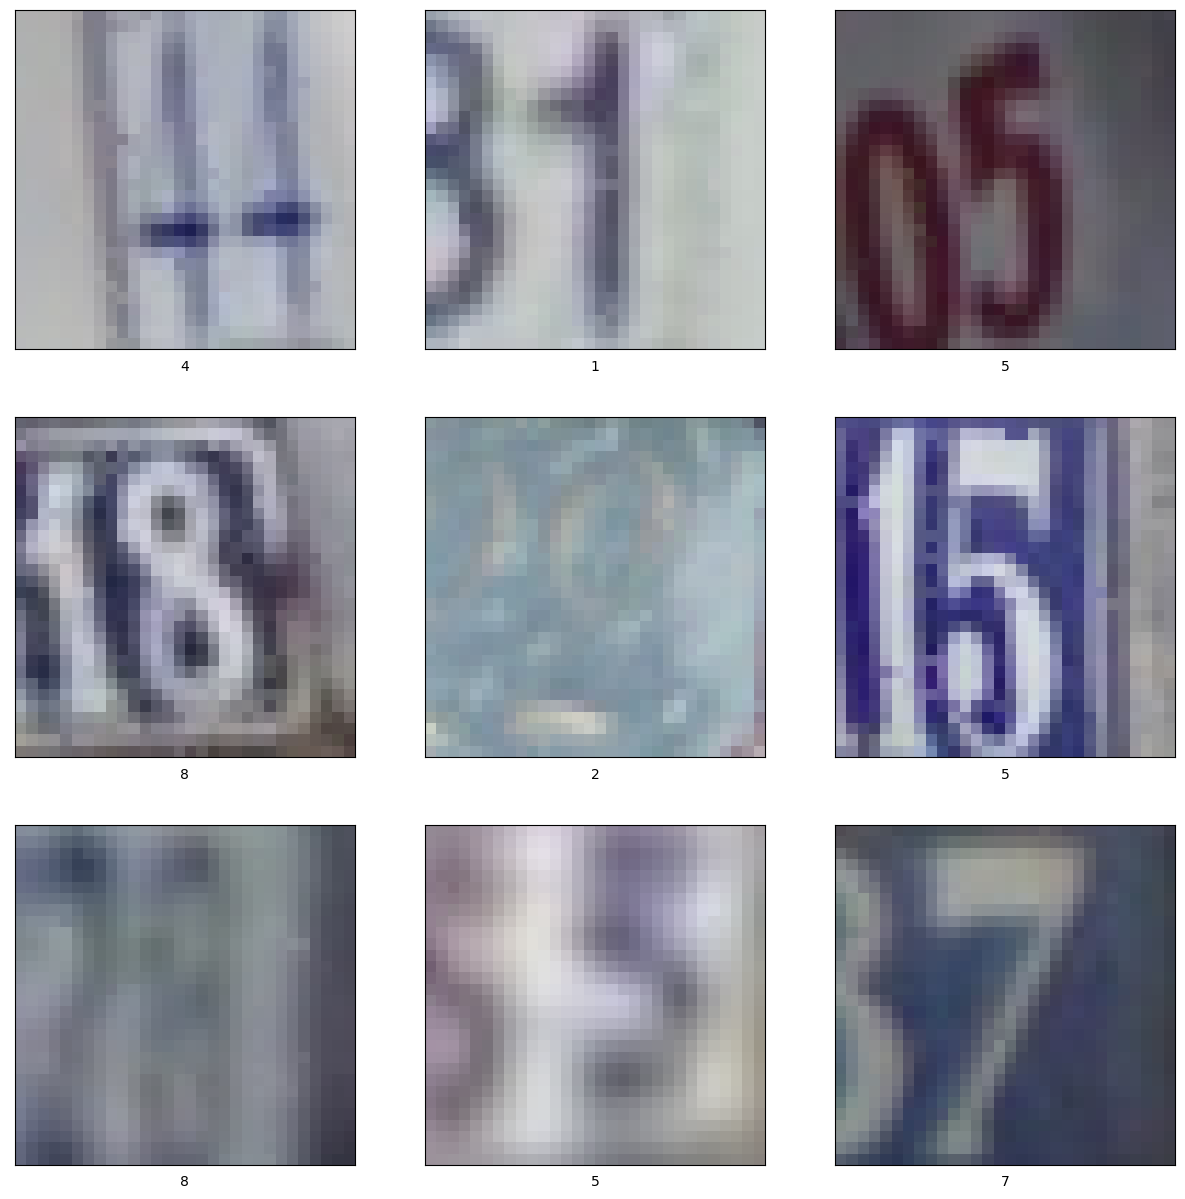

In [55]:
plt.figure(figsize=(15,15))
for i, j in zip(range(60, 100), range(9)):
    plt.subplot(3,3,j+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(arrtest[i]))
    plt.xlabel(classes[i])
plt.show()

In [56]:
with open('13.csv', 'w') as f:
    f.write('Id,Category\n')
    for i, j in enumerate(classes):
        f.write(f'{i},{j}\n')

In [ ]:
f1 = 'submissionadam4.csv'
f2 = 'submissionadam5.csv'
for i, j in zip(open(f1, 'r').readlines(), open(f2, 'r').readlines()):
    if i != j:
        print(i, j)

In [ ]:

plt.imshow(np.array(arrtest[137]))


In [62]:
mod = tf.keras.models.load_model('CHECKPOINTS/')

In [63]:
predictions = mod.predict(arrtest)
classes = np.argmax(predictions, axis=1)
classes
# 5 4 1 ... 0 9 2

  1/782 [..............................] - ETA: 2:52

2022-12-11 16:03:49.715078: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


782/782 [==============================] - 7s 9ms/step


array([5, 4, 1, ..., 0, 9, 2])

In [64]:
with open('15bestacc.csv', 'w') as f:
    f.write('Id,Category\n')
    for i, j in enumerate(classes):
        f.write(f'{i},{j}\n')